<a href="https://colab.research.google.com/github/zenku663-svg/ecommerce-sales-pluto-academy/blob/main/ECommerce_Sales_Analysis_Project01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Load all 3 datasets
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

print("Orders shape:", orders.shape)
print("Items shape:", items.shape)
print("Products shape:", products.shape)

Orders shape: (99441, 8)
Items shape: (112650, 7)
Products shape: (32951, 9)


In [ ]:
print("=== Orders ===")
print(orders.isnull().sum())
print("\n=== Items ===")
print(items.isnull().sum())
print("\n=== Products ===")
print(products.isnull().sum())

=== Orders ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== Items ===
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

=== Products ===
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [ ]:
products['product_category_name'] = products['product_category_name'].fillna('Unknown')

orders = orders.dropna(subset=['order_approved_at'])

for col in ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    products[col] = products[col].fillna(products[col].median())

df = orders.merge(items, on='order_id', how='inner')
df = df.merge(products, on='product_id', how='inner')

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['month'] = df['order_purchase_timestamp'].dt.month
df['year'] = df['order_purchase_timestamp'].dt.year

print("Merged dataset shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
df.head()

Merged dataset shape: (112635, 24)

Missing values: 8454


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,month,year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,7,2018
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,8,2018
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,11,2017
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,2,2018


In [ ]:
df['revenue'] = df['price'] + df['freight_value']
top_categories = df.groupby('product_category_name')['revenue'].sum().sort_values(ascending=False).head(10)
print("=== Q1: Top 10 Categories by Revenue ===")
print(top_categories)

monthly_sales = df.groupby(['year','month'])['revenue'].sum()
print("\n=== Q2: Monthly Sales ===")
print(monthly_sales)

avg_order = df.groupby('order_id')['revenue'].sum().mean()
print("\n=== Q3: Average Order Value ===")
print(f"R$ {avg_order:.2f}")

top_orders = df.groupby('product_category_name')['order_id'].count().sort_values(ascending=False).head(10)
print("\n=== Q4: Top Categories by Orders ===")
print(top_orders)

print("\n=== Q5: Order Status Distribution ===")
print(df['order_status'].value_counts())

=== Q1: Top 10 Categories by Revenue ===
product_category_name
beleza_saude              1441248.07
relogios_presentes        1305541.61
cama_mesa_banho           1241524.53
esporte_lazer             1156562.02
informatica_acessorios    1059272.40
moveis_decoracao           902210.88
utilidades_domesticas      778397.77
cool_stuff                 719020.57
automotivo                 685384.32
ferramentas_jardim         584064.98
Name: revenue, dtype: float64

=== Q2: Monthly Sales ===
year  month
2016  9            354.75
      10         56808.84
      12            19.62
2017  1         137073.56
      2         284440.95
      3         432048.59
      4         412422.24
      5         586190.95
      6         502963.04
      7         584971.62
      8         668204.60
      9         720398.91
      10        769312.37
      11       1179143.77
      12        863547.23
2018  1        1107301.89
      2         986908.96
      3        1155126.82
      4        1159698.04
    

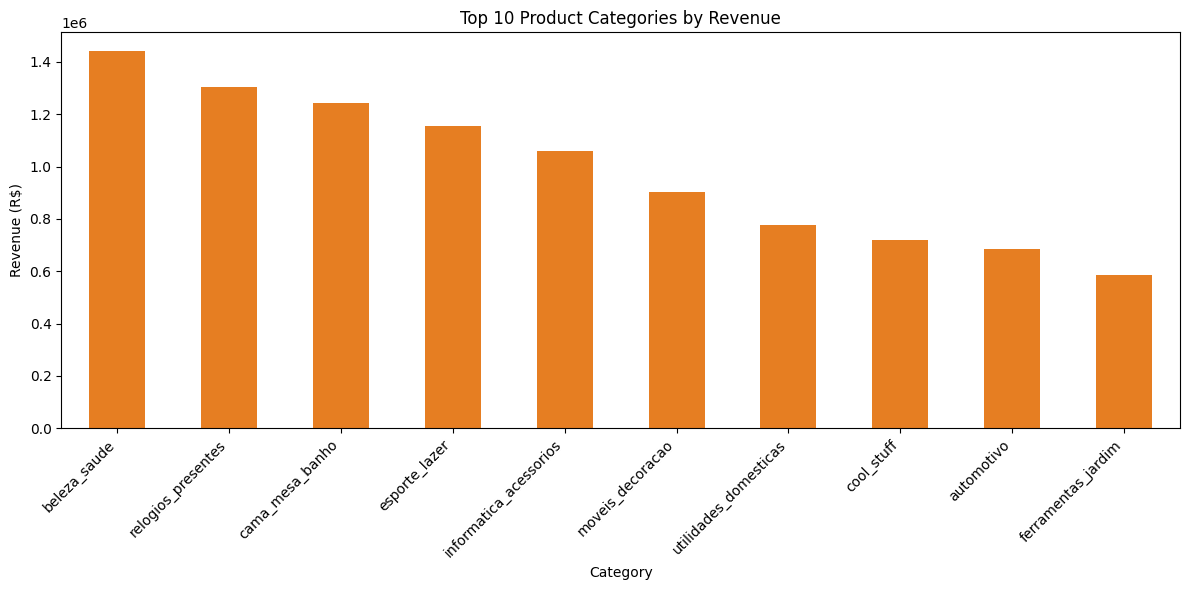

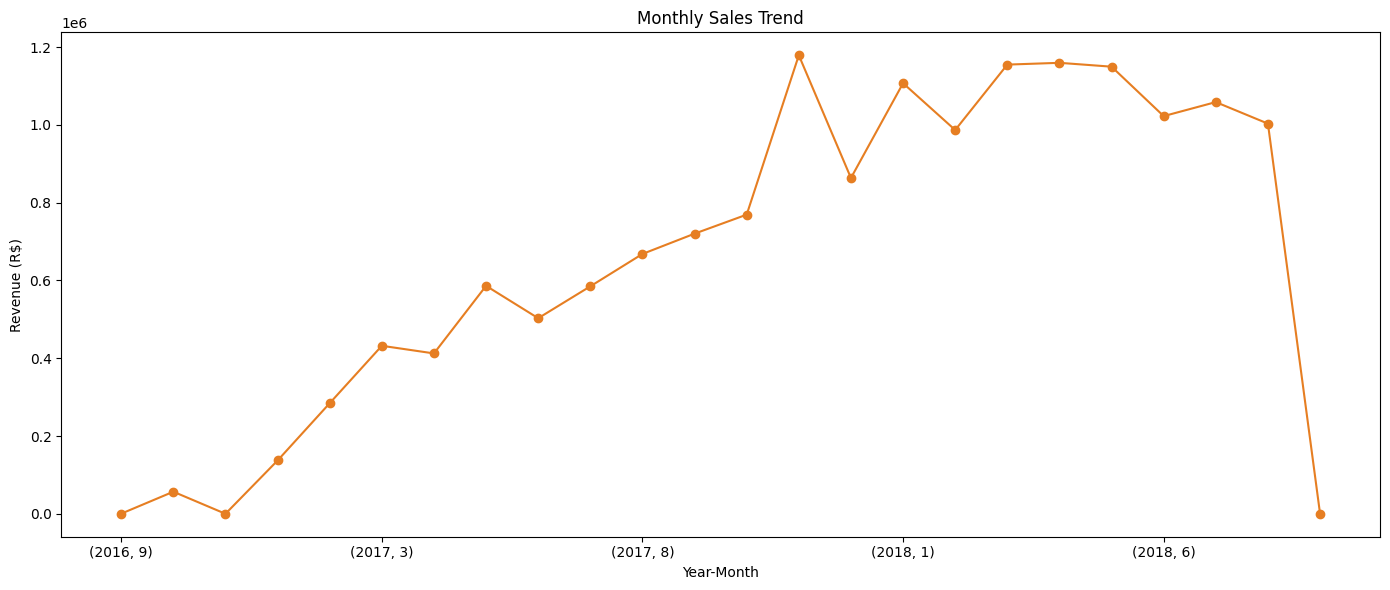

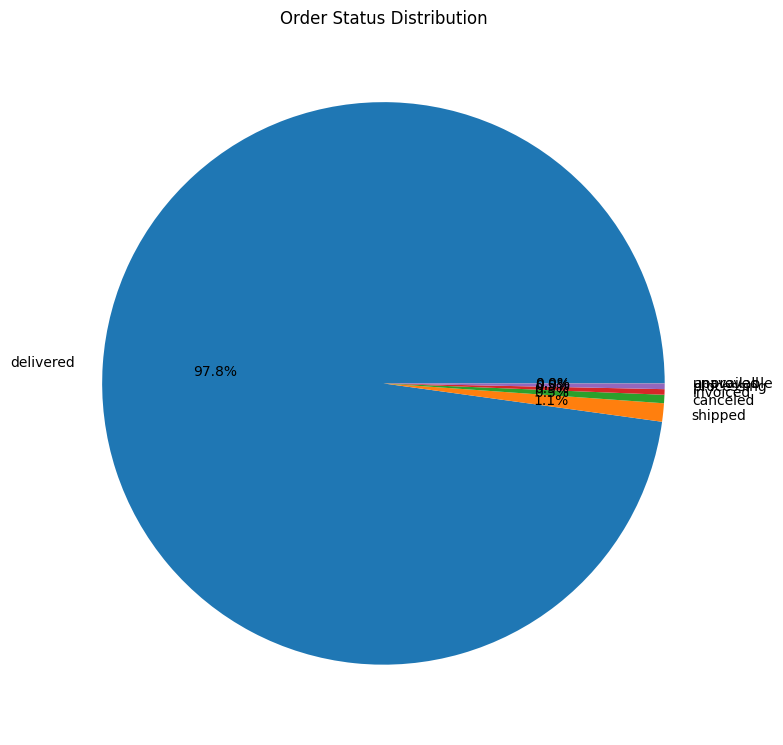

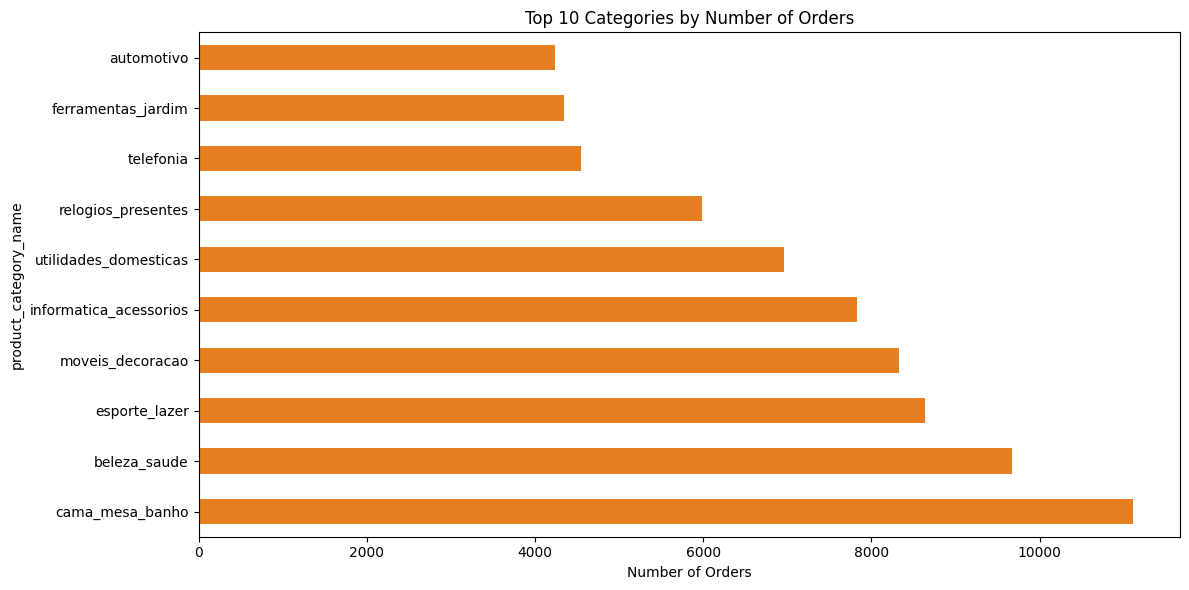

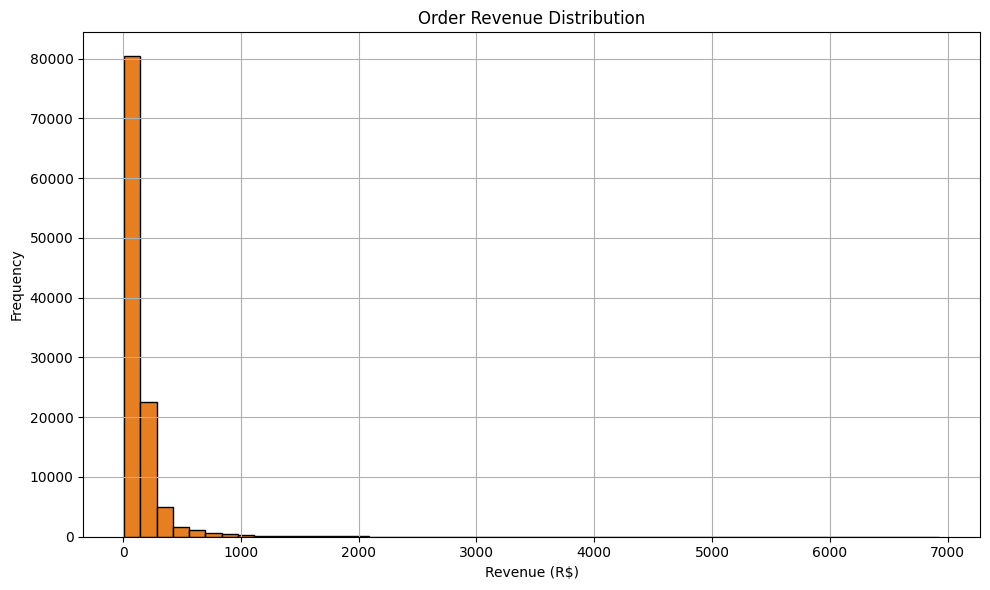

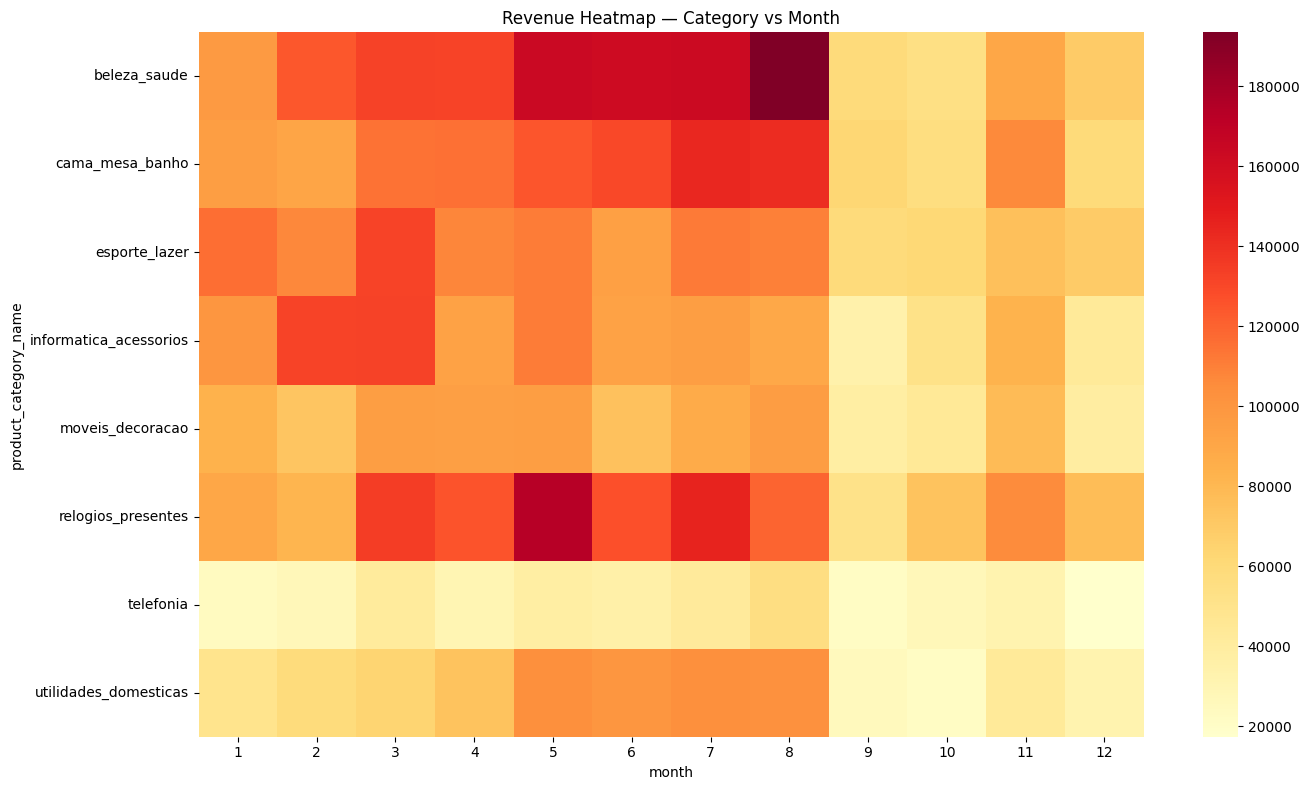

All 6 charts done!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1
plt.figure(figsize=(12,6))
top_categories.plot(kind='bar', color='#E67E22')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart1_revenue.png')
plt.show()

# Chart 2
plt.figure(figsize=(14,6))
monthly_sales.plot(kind='line', marker='o', color='#E67E22')
plt.title('Monthly Sales Trend')
plt.xlabel('Year-Month')
plt.ylabel('Revenue (R$)')
plt.tight_layout()
plt.savefig('chart2_monthly.png')
plt.show()

# Chart 3
plt.figure(figsize=(8,8))
df['order_status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Order Status Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('chart3_status.png')
plt.show()

# Chart 4
plt.figure(figsize=(12,6))
top_orders.plot(kind='barh', color='#E67E22')
plt.title('Top 10 Categories by Number of Orders')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.savefig('chart4_orders.png')
plt.show()

# Chart 5
plt.figure(figsize=(10,6))
df['revenue'].hist(bins=50, color='#E67E22', edgecolor='black')
plt.title('Order Revenue Distribution')
plt.xlabel('Revenue (R$)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('chart5_histogram.png')
plt.show()

# Chart 6
plt.figure(figsize=(14,8))
top_cats = df['product_category_name'].value_counts().head(8).index
heatmap_data = df[df['product_category_name'].isin(top_cats)].groupby(
    ['product_category_name','month'])['revenue'].sum().unstack()
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False)
plt.title('Revenue Heatmap — Category vs Month')
plt.tight_layout()
plt.savefig('chart6_heatmap.png')
plt.show()

print("All 6 charts done!")

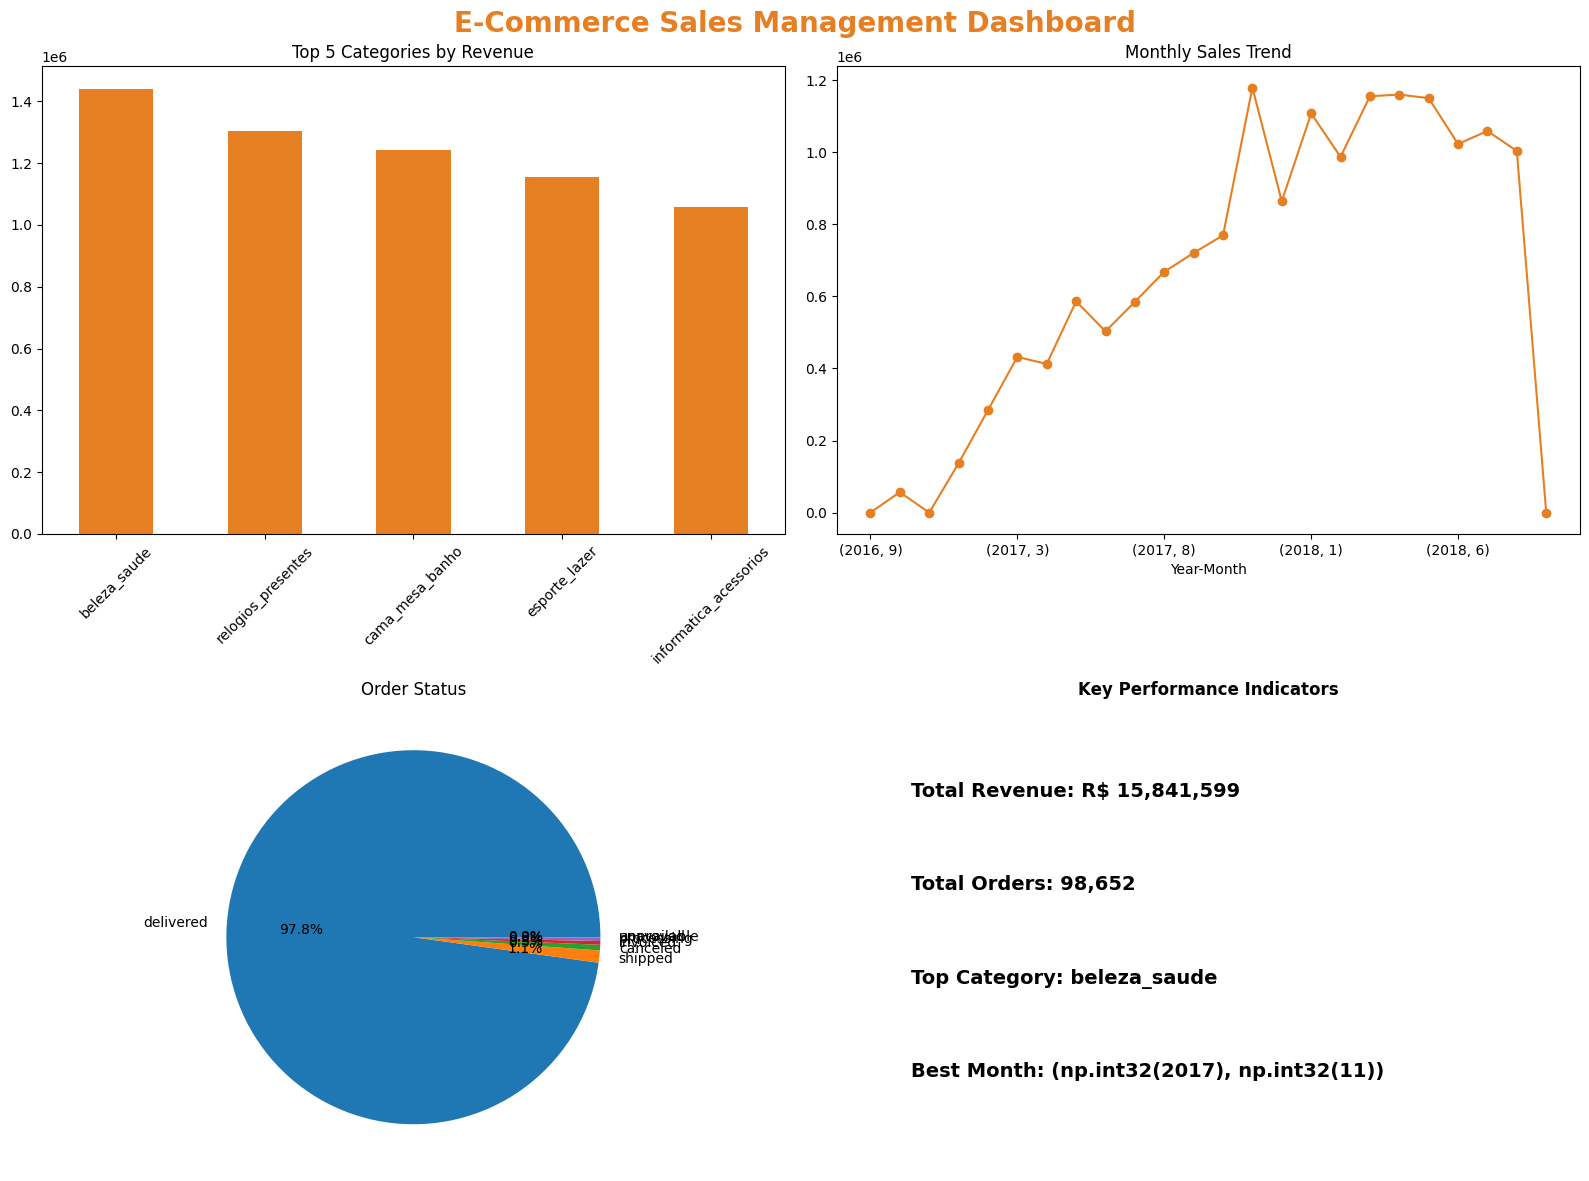

Dashboard created!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('E-Commerce Sales Management Dashboard',
             fontsize=20, fontweight='bold', color='#E67E22')

total_revenue = df['revenue'].sum()
total_orders = df['order_id'].nunique()
top_cat = top_categories.index[0]
best_month = monthly_sales.idxmax()

ax1 = axes[0, 0]
top_categories.head(5).plot(kind='bar', ax=ax1, color='#E67E22')
ax1.set_title('Top 5 Categories by Revenue')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)

ax2 = axes[0, 1]
monthly_sales.plot(kind='line', ax=ax2, marker='o', color='#E67E22')
ax2.set_title('Monthly Sales Trend')
ax2.set_xlabel('Year-Month')

ax3 = axes[1, 0]
df['order_status'].value_counts().plot(kind='pie', ax=ax3, autopct='%1.1f%%')
ax3.set_title('Order Status')
ax3.set_ylabel('')

ax4 = axes[1, 1]
ax4.axis('off')
ax4.text(0.1, 0.8, f'Total Revenue: R$ {total_revenue:,.0f}',
         fontsize=14, fontweight='bold')
ax4.text(0.1, 0.6, f'Total Orders: {total_orders:,}',
         fontsize=14, fontweight='bold')
ax4.text(0.1, 0.4, f'Top Category: {top_cat}',
         fontsize=14, fontweight='bold')
ax4.text(0.1, 0.2, f'Best Month: {best_month}',
         fontsize=14, fontweight='bold')
ax4.set_title('Key Performance Indicators', fontweight='bold')

plt.tight_layout()
plt.savefig('dashboard.png')
plt.show()

print("Dashboard created!")

In [ ]:
print("""
BUSINESS INSIGHTS REPORT — E-Commerce Sales Analysis
=====================================================

Insight 1: Beauty & Health is the Top Revenue Category
beleza_saude generated R$1,441,248 in revenue — the highest among
all categories. The business should invest more in this category
through promotions and wider product range.

Insight 2: November 2017 Was the Peak Sales Month
November 2017 recorded R$1,179,143 in sales — likely due to
Black Friday. The business should prepare extra inventory and
marketing campaigns every November.

Insight 3: Average Order Value is R$160.58
Customers spend R$160 per order on average. Introducing bundle
offers or free shipping above R$200 could increase this value.

Insight 4: 98% Orders Successfully Delivered
110,182 out of 112,635 orders were delivered successfully.
Only 542 cancellations — showing strong operational efficiency.

Insight 5: Bed, Bath & Table Has Most Orders
cama_mesa_banho has 11,114 orders — most popular by volume.
Combined with beleza_saude revenue dominance, home and personal
care products are the core business drivers.
""")


BUSINESS INSIGHTS REPORT — E-Commerce Sales Analysis

Insight 1: Beauty & Health is the Top Revenue Category
beleza_saude generated R$1,441,248 in revenue — the highest among
all categories. The business should invest more in this category
through promotions and wider product range.

Insight 2: November 2017 Was the Peak Sales Month
November 2017 recorded R$1,179,143 in sales — likely due to
Black Friday. The business should prepare extra inventory and
marketing campaigns every November.

Insight 3: Average Order Value is R$160.58
Customers spend R$160 per order on average. Introducing bundle
offers or free shipping above R$200 could increase this value.

Insight 4: 98% Orders Successfully Delivered
110,182 out of 112,635 orders were delivered successfully.
Only 542 cancellations — showing strong operational efficiency.

Insight 5: Bed, Bath & Table Has Most Orders
cama_mesa_banho has 11,114 orders — most popular by volume.
Combined with beleza_saude revenue dominance, home and person